In [1]:
import os
os.listdir('.')

['.prompts',
 'two_param_stability_all_Lfunctions.csv',
 '.config',
 'omega_class_moments_N1e6.csv',
 'memory',
 '.kernel_llm_logs_1.txt']

In [2]:
import pandas as pd
df = pd.read_csv('omega_class_moments_N1e6.csv')
print(df)
print()
stab = pd.read_csv('two_param_stability_all_Lfunctions.csv')
print(stab)

 L_function N_terms M_total M_0 M_1 M_2 \
0 zeta 10000 14049.610398 500.0 1965.747008 6483.537674 
1 zeta 50000 52555.776641 500.0 3208.301641 21414.200073 
2 zeta 100000 98775.232940 500.0 4480.038022 37384.580762 
3 L(Δ) 10000 2161.019922 500.0 976.303859 566.192078 
4 L(Δ) 50000 2348.222814 500.0 1033.094242 641.389207 
5 L(Δ) 100000 2428.171224 500.0 1050.861296 676.608911 
6 L_DH 10000 2025.689869 500.0 618.478717 717.769427 
7 L_DH 50000 2186.052439 500.0 639.066491 784.006896 
8 L_DH 100000 2238.888403 500.0 644.808316 800.888886 
9 zeta 1000000 884001.871616 500.0 21169.883300 264592.121329 
10 L(Δ) 1000000 2676.505424 500.0 1098.486340 781.974004 
11 L_DH 1000000 2432.632471 500.0 663.110599 873.431509 

 M_3 M_4 M_geq5 frac_0 frac_1 frac_2 \
0 4759.568118 337.922395 2.835203 0.035588 0.139915 0.461475 
1 24096.365734 3301.861669 35.047524 0.009514 0.061046 0.407457 
2 48011.972434 8267.691145 130.950577 0.005062 0.045356 0.378481 
3 113.409894 5.078208 0.035883 0.231372 0.451

In [3]:
import numpy as np
import statsmodels.api as sm

Ns_4 = [10_000, 50_000, 100_000, 1_000_000]
Ns_3 = [10_000, 50_000, 100_000]

def regressors(Ns):
 Ns = np.array(Ns, dtype=float)
 logN = np.log(Ns)
 loglogN = np.log(logN)
 logloglogN = np.log(loglogN)
 x1 = loglogN
 x2 = logloglogN / loglogN
 return x1, x2

def fit_model(Ns, M_vals):
 x1, x2 = regressors(Ns)
 y = np.log(np.array(M_vals, dtype=float))
 X = np.column_stack([np.ones_like(x1), x1, x2])
 model = sm.OLS(y, X).fit()
 # params: [logC, alpha, beta]
 return model

# Build the result
ks = ['M_1', 'M_2', 'M_3', 'M_4']
L_funcs = ['zeta', 'L(Δ)', 'L_DH']

records = []
for L in L_funcs:
 sub = df[df['L_function'] == L].set_index('N_terms')
 for k in ks:
 # 4-point
 Mvals_4 = [sub.loc[N, k] for N in Ns_4]
 Mvals_3 = [sub.loc[N, k] for N in Ns_3]
 m4 = fit_model(Ns_4, Mvals_4)
 m3 = fit_model(Ns_3, Mvals_3)
 
 alpha4 = m4.params[1]; beta4 = m4.params[2]
 alpha3 = m3.params[1]; beta3 = m3.params[2]
 # standard errors
 se_alpha4 = m4.bse[1]; se_beta4 = m4.bse[2]
 # For 3-point fit with 3 params, df_resid=0, std errors undefined
 try:
 se_alpha3 = m3.bse[1]
 se_beta3 = m3.bse[2]
 except Exception:
 se_alpha3 = np.nan; se_beta3 = np.nan
 
 pct_alpha = (alpha4 - alpha3) / alpha3 * 100 if alpha3 != 0 else np.nan
 pct_beta = (beta4 - beta3) / beta3 * 100 if beta3 != 0 else np.nan
 
 records.append({
 'L_function': L, 'k': k,
 'alpha_4pt': alpha4, 'beta_4pt': beta4,
 'se_alpha_4pt': se_alpha4, 'se_beta_4pt': se_beta4,
 'R2_4pt': m4.rsquared,
 'alpha_3pt': alpha3, 'beta_3pt': beta3,
 'pct_change_alpha': pct_alpha, 'pct_change_beta': pct_beta,
 })

result = pd.DataFrame(records)
pd.set_option('display.float_format', '{:.4f}'.format)
print(result.to_string(index=False))

L_function k alpha_4pt beta_4pt se_alpha_4pt se_beta_4pt R2_4pt alpha_3pt beta_3pt pct_change_alpha pct_change_beta
 zeta M_1 11.3563 -265.7211 0.2808 13.1362 0.9998 9.6646 -208.7618 17.5038 27.2844
 zeta M_2 12.4733 -160.7109 0.1072 5.0127 1.0000 11.8277 -138.9753 5.4579 15.6399
 zeta M_3 13.4926 -108.9247 0.0825 3.8581 1.0000 12.9958 -92.1956 3.8232 18.1452
 zeta M_4 16.0860 -61.2340 0.0251 1.1718 1.0000 15.9351 -56.1529 0.9470 9.0488
 L(Δ) M_1 0.1825 5.2105 0.0080 0.3747 0.9999 0.1342 6.8352 35.9479 -23.7691
 L(Δ) M_2 0.8159 -0.8718 0.0339 1.5838 0.9999 1.0198 -7.7393 -19.9994 -88.7349
 L(Δ) M_3 1.8449 8.6674 0.0443 2.0712 1.0000 2.1116 -0.3135 -12.6316 -2864.7716
 L(Δ) M_4 1.9700 139.1121 0.2299 10.7524 0.9998 0.5853 185.7350 236.5584 -25.1018
 L_DH M_1 0.1219 2.3814 0.0144 0.6729 0.9994 0.0352 5.2991 246.0728 -55.0603
 L_DH M_2 0.4114 3.3546 0.0738 3.4525 0.9981 -0.0333 18.3247 -1336.9828 -81.6936
 L_DH M_3 1.1538 20.1113 0.1130 5.2873 0.9996 0.4729 43.0374 143.9985 -53.2701
 L_DH

/app/kernel_env/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
 return np.dot(wresid, wresid) / self.df_resid


In [4]:
# Compare to the original (a,b) stability in two_param_stability_all_Lfunctions.csv
# That CSV has pct_change_a and pct_change_b for the same (L, k) combos (excluding M_geq5 we don't need)
orig = stab[stab['k'].isin(ks)].copy()
orig_compact = orig[['L', 'k', 'pct_change_a', 'pct_change_b']].rename(columns={'L':'L_function'})
merged = result.merge(orig_compact, on=['L_function', 'k'])
print(merged[['L_function','k','pct_change_alpha','pct_change_beta','pct_change_a','pct_change_b']].to_string(index=False))

L_function k pct_change_alpha pct_change_beta pct_change_a pct_change_b
 zeta M_1 17.5038 27.2844 17.4794 18.7003
 zeta M_2 5.4579 15.6399 6.3351 7.8103
 zeta M_3 3.8232 18.1452 6.9190 10.1533
 zeta M_4 0.9470 9.0488 0.7963 1.6463
 L(Δ) M_1 35.9479 -23.7691 -36.6314 -29.0452
 L(Δ) M_2 -19.9994 -88.7349 -62.8471 -89.8015
 L(Δ) M_3 -12.6316 -2864.7716 -92.0866 -2685.9647
 L(Δ) M_4 236.5584 -25.1018 -35.1348 -30.2916
 L_DH M_1 246.0728 -55.0603 -68.8030 -58.3089
 L_DH M_2 -1336.9828 -81.6936 -94.2416 -83.2165
 L_DH M_3 143.9985 -53.2701 -68.2970 -56.6346
 L_DH M_4 -51.4270 -157.8377 -122.7299 -154.4268


In [5]:
# Compute |pct change| summaries
result['abs_pct_alpha'] = result['pct_change_alpha'].abs()
result['abs_pct_beta'] = result['pct_change_beta'].abs()
merged['abs_pct_alpha'] = merged['pct_change_alpha'].abs()
merged['abs_pct_beta'] = merged['pct_change_beta'].abs()
merged['abs_pct_a'] = merged['pct_change_a'].abs()
merged['abs_pct_b'] = merged['pct_change_b'].abs()

summary = merged.groupby('L_function')[['abs_pct_alpha','abs_pct_beta','abs_pct_a','abs_pct_b']].median()
print("Median |% change| by L-function (across M_1..M_4):")
print(summary)

print()
print("Mean |% change| by L-function:")
print(merged.groupby('L_function')[['abs_pct_alpha','abs_pct_beta','abs_pct_a','abs_pct_b']].mean())

Median |% change| by L-function (across M_1..M_4):
 abs_pct_alpha abs_pct_beta abs_pct_a abs_pct_b
L_function 
L(Δ) 27.9737 56.9184 49.7392 60.0466
L_DH 195.0356 68.3770 81.5223 70.7627
zeta 4.6405 16.8926 6.6270 8.9818

Mean |% change| by L-function:
 abs_pct_alpha abs_pct_beta abs_pct_a abs_pct_b
L_function 
L(Δ) 76.2843 750.5944 56.6750 708.7757
L_DH 444.6203 86.9654 88.5179 88.1467
zeta 6.9330 17.5296 7.8824 9.5775


In [6]:
# Save reparameterized stability table
out = result[['L_function','k','alpha_4pt','beta_4pt','se_alpha_4pt','se_beta_4pt','R2_4pt',
 'alpha_3pt','beta_3pt','pct_change_alpha','pct_change_beta']]
out.to_csv('two_param_stability_reparam_all_Lfunctions.csv', index=False)
print("Saved.")
print(out.to_string(index=False))

Saved.
L_function k alpha_4pt beta_4pt se_alpha_4pt se_beta_4pt R2_4pt alpha_3pt beta_3pt pct_change_alpha pct_change_beta
 zeta M_1 11.3563 -265.7211 0.2808 13.1362 0.9998 9.6646 -208.7618 17.5038 27.2844
 zeta M_2 12.4733 -160.7109 0.1072 5.0127 1.0000 11.8277 -138.9753 5.4579 15.6399
 zeta M_3 13.4926 -108.9247 0.0825 3.8581 1.0000 12.9958 -92.1956 3.8232 18.1452
 zeta M_4 16.0860 -61.2340 0.0251 1.1718 1.0000 15.9351 -56.1529 0.9470 9.0488
 L(Δ) M_1 0.1825 5.2105 0.0080 0.3747 0.9999 0.1342 6.8352 35.9479 -23.7691
 L(Δ) M_2 0.8159 -0.8718 0.0339 1.5838 0.9999 1.0198 -7.7393 -19.9994 -88.7349
 L(Δ) M_3 1.8449 8.6674 0.0443 2.0712 1.0000 2.1116 -0.3135 -12.6316 -2864.7716
 L(Δ) M_4 1.9700 139.1121 0.2299 10.7524 0.9998 0.5853 185.7350 236.5584 -25.1018
 L_DH M_1 0.1219 2.3814 0.0144 0.6729 0.9994 0.0352 5.2991 246.0728 -55.0603
 L_DH M_2 0.4114 3.3546 0.0738 3.4525 0.9981 -0.0333 18.3247 -1336.9828 -81.6936
 L_DH M_3 1.1538 20.1113 0.1130 5.2873 0.9996 0.4729 43.0374 143.9985 -53.270

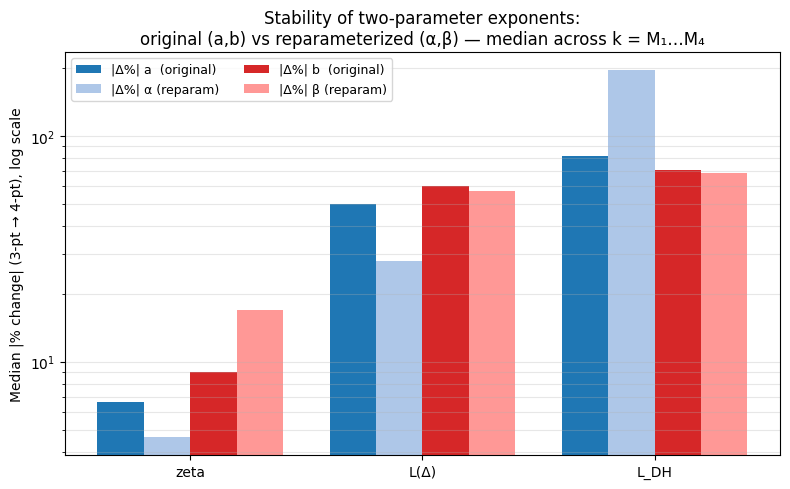

Figure saved.


In [7]:
# Final figure: compare reparam vs original median |% change|
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

L_order = ['zeta', 'L(Δ)', 'L_DH']
x = np.arange(len(L_order))
width = 0.2

med = merged.groupby('L_function')[['abs_pct_alpha','abs_pct_beta','abs_pct_a','abs_pct_b']].median().reindex(L_order)

ax.bar(x - 1.5*width, med['abs_pct_a'], width, label='|Δ%| a (original)', color='#1f77b4')
ax.bar(x - 0.5*width, med['abs_pct_alpha'], width, label='|Δ%| α (reparam)', color='#aec7e8')
ax.bar(x + 0.5*width, med['abs_pct_b'], width, label='|Δ%| b (original)', color='#d62728')
ax.bar(x + 1.5*width, med['abs_pct_beta'], width, label='|Δ%| β (reparam)', color='#ff9896')

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(L_order)
ax.set_ylabel('Median |% change| (3-pt → 4-pt), log scale')
ax.set_title('Stability of two-parameter exponents:\noriginal (a,b) vs reparameterized (α,β) — median across k = M₁…M₄')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3, which='both', axis='y')

plt.tight_layout()
plt.savefig('reparam_stability_comparison.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure saved.")